# Works for 0d, 1d, 2d and 3d periodic Hamiltonians, including Nambu/BdG

`get_wannier_hamiltonian` builds its own wannierization-mesh reciprocal-lattice geometry
directly from the Hamiltonian's periodic dimensionality, so it works unchanged whether $H(k)$
depends on zero, one, two or three quasimomentum components. A genuinely $0d$ (finite, molecular
or island) Hamiltonian has no Bloch phases of its own, so the standard trick is to wrap it as a
fake, extremely large-period $1d$ chain (`dimensionality=1`, a lattice vector far longer than any
hopping range) and Wannierize with a single, $\Gamma$-point-only mesh (`nk=1`); periodic images
never couple, so this exactly reproduces the finite spectrum.

For superconducting (Nambu/BdG, `h.has_eh=True`) Hamiltonians, the method additionally
*enforces* electron-hole (particle-hole) symmetry on the result: the returned Hamiltonian's
real-space hoppings satisfy $C\,h_R^*\,C^{-1} = -h_R$ exactly, for the unitary operator $C$
stored as `hwan.wannier_particle_hole_operator`. Because a Nambu spectrum is symmetric under
$E\to-E$, the band range must be closed under the particle-hole pairing (centred on the gap).

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

In [2]:
from pyqula import islands
from pyqula.hamiltonians import Hamiltonian
from pyqula.multihopping import MultiHopping

# --- 0d: a small triangular island, wrapped as a fake huge-period 1d chain ---
g0 = islands.get_geometry(name="triangular", n=1.4, nedges=3)
h0 = g0.get_hamiltonian(has_spin=False)
n0 = h0.intra.shape[0]

g0d = h0.geometry.copy()
g0d.dimensionality = 1
g0d.a1 = np.array([1000.,0.,0.]) # periodic images never couple
hfake = Hamiltonian(g0d)
hfake.has_spin = h0.has_spin
hfake.is_sparse = False
hfake.is_multicell = True
hfake.set_multihopping(MultiHopping({(0,0,0): np.array(h0.intra)}))

mid0 = n0//2
hwan0 = hfake.get_wannier_hamiltonian(bands=[mid0-1,mid0],nk=1,num_iter=1000)
e_ref0 = np.sort(np.linalg.eigvalsh(h0.intra))[[mid0-1,mid0]]
e_wan0 = np.sort(np.linalg.eigvalsh(hwan0.intra))
print("0d (island, Gamma-point trick): max error =",np.max(np.abs(e_ref0-e_wan0)))

# --- 1d, 2d, 3d: same call, increasing periodic dimensionality ---
results = {}
g1 = geometry.chain() ; h1 = g1.get_hamiltonian(has_spin=False)
results["1d (chain)"] = h1.get_wannier_hamiltonian(bands=[0,0],nk=16)

g2 = geometry.honeycomb_lattice() ; h2 = g2.get_hamiltonian(has_spin=False)
h2.add_onsite([0.8,-0.8])
results["2d (honeycomb)"] = h2.get_wannier_hamiltonian(bands=[0,0],nk=12)

g3 = geometry.cubic_lattice() ; h3 = g3.get_hamiltonian(has_spin=False)
results["3d (cubic)"] = h3.get_wannier_hamiltonian(bands=[0,0],nk=6)

for name,hwan in results.items():
    print(f"{name}: num Wannier functions={hwan.intra.shape[0]}, total spread={hwan.wannier_spread_total:.4f}")

0d (island, Gamma-point trick): max error = 4.796163466380676e-14


1d (chain): num Wannier functions=1, total spread=0.0000
2d (honeycomb): num Wannier functions=1, total spread=0.3206
3d (cubic): num Wannier functions=1, total spread=0.0000


The Wannier functions of the island live on its sites, so `hwan0.wannier_functions` can be drawn
directly as a map. The two selected states are a degenerate pair, and the two Wannier functions are
the combinations of them with the smallest spread, each with its weight on a different set of sites
(the cross marks its Wannier centre).

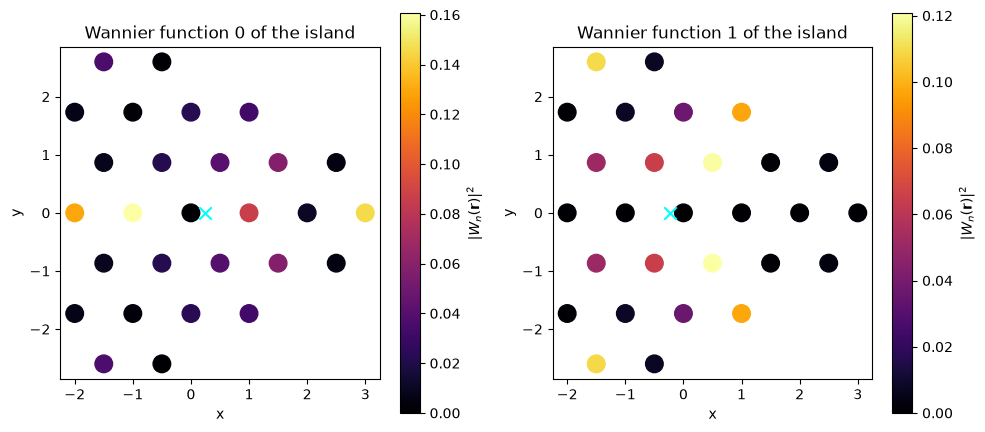

In [3]:
# real-space weight of the two Wannier functions of the island
W0 = hwan0.wannier_functions[(0,0,0)] # amplitudes on the island sites, one column per function
r0 = g0.r

fig,axs = plt.subplots(1,2,figsize=(10,4.5))
for n,ax in enumerate(axs):
    sc = ax.scatter(r0[:,0],r0[:,1],c=np.abs(W0[:,n])**2,cmap="inferno",s=160)
    plt.colorbar(sc,ax=ax,label=r"$|W_n(\mathbf{r})|^2$")
    ax.scatter(hwan0.wannier_centres[n][0],hwan0.wannier_centres[n][1],marker="x",c="cyan",s=80)
    ax.set_aspect("equal") ; ax.set_title(f"Wannier function {n} of the island")
    ax.set_xlabel("x") ; ax.set_ylabel("y")
plt.tight_layout()
plt.show()

Wannierized bands: [1, 2]
Total spread Omega: 2.7934578004798993
Max electron-hole symmetry violation: 2.685989282326823e-15


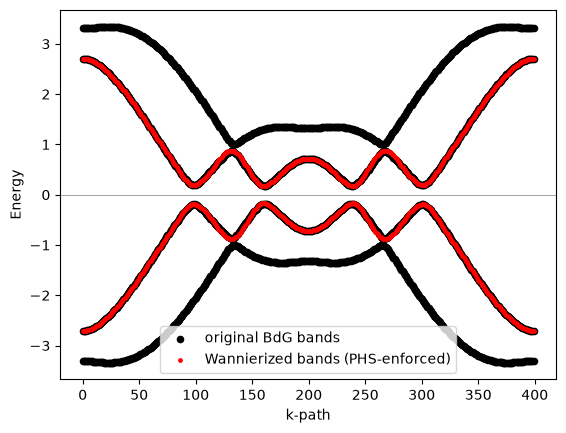

In [4]:
# --- Nambu/BdG: a 1d chain with Rashba SOC, exchange and s-wave pairing ---
g = geometry.chain()
h = g.get_hamiltonian(has_spin=True)
h.add_rashba(0.5)
h.add_exchange([0.,0.,0.3])
h.shift_fermi(1.0) # move away from particle-hole symmetric filling
h.add_swave(0.2) # turns h.has_eh on

# 1 site x 2 spin x 2 (electron/hole) = 4 bands; Wannierize the low-energy
# Bogoliubov quasiparticle pair (bands 1,2), the electron-hole-symmetric
# selection centred on the gap
hwan = h.get_wannier_hamiltonian(bands=[1,2],nk=24,num_iter=1000)

print("Wannierized bands:",hwan.wannier_band_indices)
print("Total spread Omega:",hwan.wannier_spread_total)

C = hwan.wannier_particle_hole_operator
Cinv = np.linalg.inv(C)
violation = np.max(np.abs(C@np.conjugate(hwan.intra)@Cinv + hwan.intra))
for hop in hwan.hopping:
    violation = max(violation,np.max(np.abs(C@np.conjugate(hop.m)@Cinv + hop.m)))
print("Max electron-hole symmetry violation:",violation)

(k,e) = h.get_bands(write=False)
(kw,ew) = hwan.get_bands(write=False)

plt.scatter(k,e,c="black",s=20,label="original BdG bands")
plt.scatter(kw,ew,c="red",s=6,label="Wannierized bands (PHS-enforced)")
plt.axhline(0,c="grey",lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy")
plt.legend()
plt.show()